# Import libraries & Data

In [1]:
import hyperspy.api as hs
hs.preferences.array_backend = "cupy"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

#%matplotlib qt

In [2]:
mpl.rcParams['figure.figsize'] = (12,6)
mpl.rcParams['axes.titlesize'] = 16
#mpl.rcParams['axes.xmargin'] = 0.05
mpl.rcParams['axes.ymargin'] = 0.25
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.linestyle'] = '-'
#plt.style.use('ggplot')
mpl.rcParams['lines.markersize'] = 3
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams["xtick.minor.visible"] =  False
mpl.rcParams["ytick.minor.visible"] =  False
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams["xtick.top"] = False
mpl.rcParams["ytick.right"] = False
mpl.rcParams['xtick.minor.pad'] = 10 #distance between axis and axis label
mpl.rcParams['ytick.minor.pad'] = 10
mpl.rcParams['xtick.major.pad'] = 10
mpl.rcParams['ytick.major.pad'] = 10


In [3]:
from matplotlib.colors import LinearSegmentedColormap
custom_colors = [ '#000000','#000090','#00FFFF','#00cb00','#66FF33','#ffff00','#FF9900','#ff0000','#FF00FF']
#custom_colors = [ '#000000','#000032','#000070','#00FFFF','#33ff99','#66FF33','#00cb00','#80e500','#ffff00','#ffcc00','#FF9900','#ff4c00','#ff0000','#FF00FF']
my_map = LinearSegmentedColormap.from_list("my_cmap", custom_colors, N=256)

In [4]:
# Load data
cs = hs.load(r'C:\Users\nagaa\Desktop\From28102025\Thesis\25-05-2024_LSCO_STXM_900_12h\EDS\Untitled\Sample\00_View001\View001_0000114.pts', lazy=False, rebin_energy=1,  cutoff_at_kV=20.0, downsample=1, sum_frames=True, only_valid_data=True, read_em_image=True)


In [5]:
data1 = cs[0].isig[0.0:20.0].deepcopy()

In [6]:
data1.data.shape

(1024, 1024, 2000)

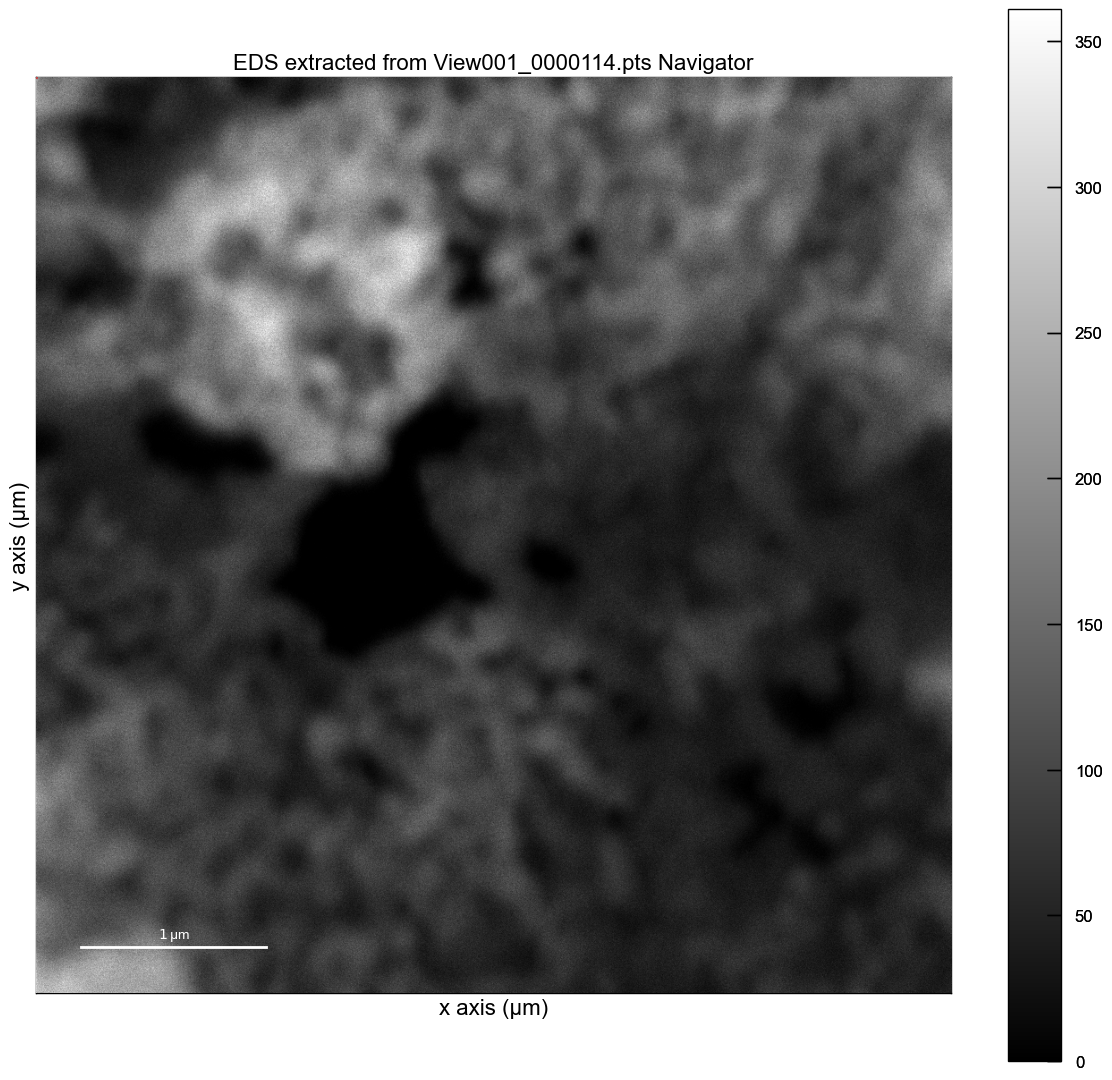

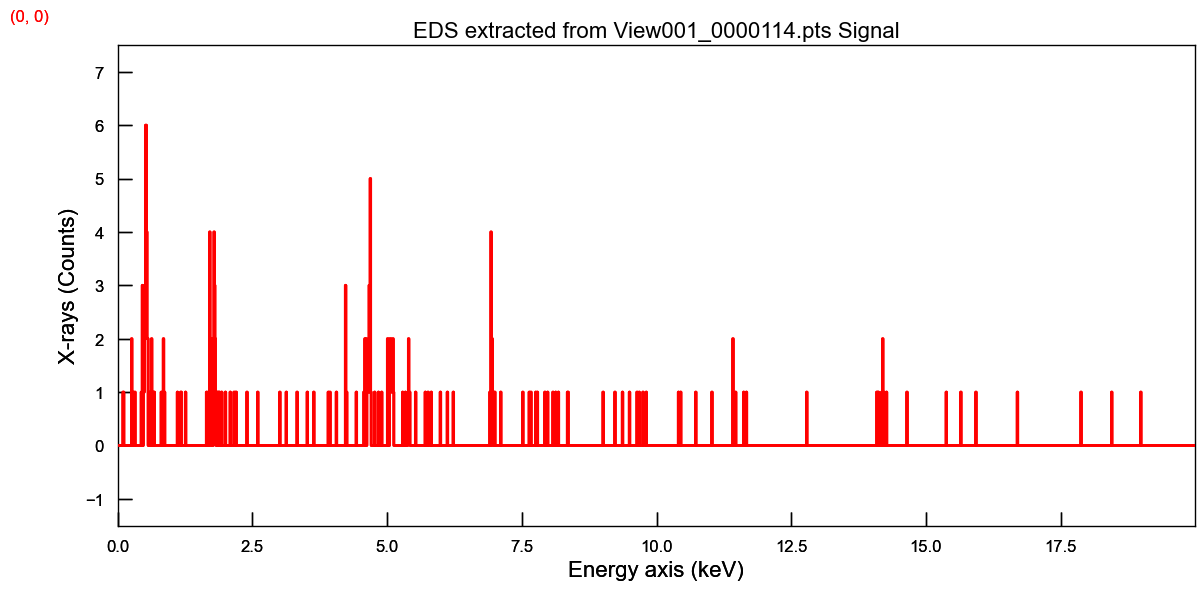

In [7]:
data1.plot()

In [ ]:
data1.sum().plot()

In [8]:
data1 = data1.rebin(scale=(2,2,1))#if required

In [9]:
background_image = cs[1].rebin(scale=(2,2))#if required

In [10]:
data1.axes_manager[0].scale*=1000
data1.axes_manager[0].units = 'nm'
data1.axes_manager[1].scale*=1000
data1.axes_manager[1].units = 'nm'

In [11]:
data1.set_elements(['Co','La','Sr','Cu','C','O','Fe'])
data1.add_lines(['Sr_Ka','Sr_La','Sr_Lb1','La_La','La_Lb1','La_Lb2','La_Lg1','La_Lg3','La_Lb3','La_Lb4','Co_Ka','Co_Kb','Co_La','Cu_Ka','Cu_Kb','Cu_La','Fe_Ka'])

In [12]:
data1.set_microscope_parameters(beam_energy=data1.original_metadata['PTTD Cond']['Meas Cond']['CONDPAGE1_SEM']['AccKV'],
    live_time=data1.original_metadata['PTTD Data']['AnalyzableMap MeasData']['Doc']['LiveTime'],
    tilt_stage=0,
    azimuth_angle=90,
    elevation_angle=21.5,
    energy_resolution_MnKa=133,
    beam_current=data1.original_metadata['PTTD Cond']['Meas Cond']['CONDPAGE1_SEM']['AccNA'],
    probe_area=data1.axes_manager[0].scale,
    real_time=data1.original_metadata['PTTD Data']['AnalyzableMap MeasData']['Doc']['RealTime'],
    display=True,
    toolkit=None)

# Masking the vacuum pixels

In [13]:
total_counts = np.sum(data1.data, axis=2)

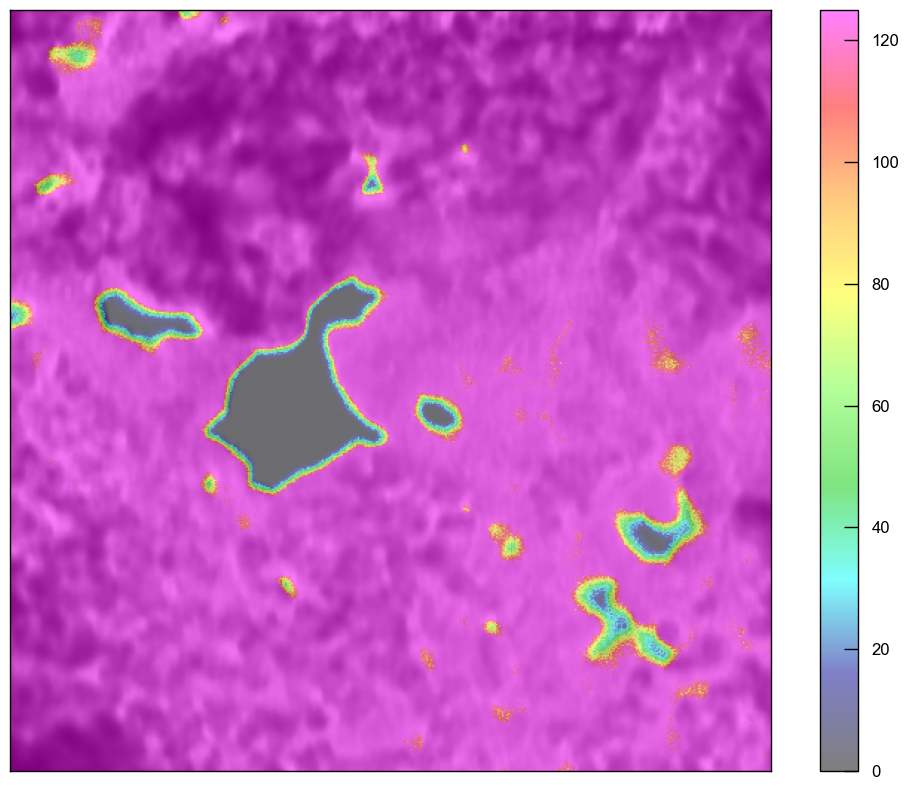

In [14]:
ax1 = plt.figure(figsize=(10,8))

# Plot first image with cmap1
plt.imshow(background_image, cmap='gray', alpha=1.0)  # Background image

plt.imshow(total_counts, cmap = my_map, alpha = 0.5, vmin= 0, vmax = 125)#125 for 128, #35 for 256
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'vacuum_mask.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [15]:
Sr_counts = np.sum(data1.isig[13.9:14.4].data, axis = 2)

In [16]:
threshold = 125 #manually adjusted
vacuum_mask = total_counts < threshold

In [17]:
num_total_pixels = total_counts.size               # total pixels (e.g., 512×512)
num_nonvacuum = np.sum(~vacuum_mask)              # ~ = logical NOT
fraction_nonvacuum = num_nonvacuum / num_total_pixels

print(f"Fraction of non-vacuum pixels: {fraction_nonvacuum:.2%}")


Fraction of non-vacuum pixels: 91.60%


In [18]:
# Define Sr-zero map
sr_zero_mask = Sr_counts < 1

# Restrict to non-vacuum region
zero_sr_in_nonvacuum = np.sum(sr_zero_mask & ~vacuum_mask)

fraction_zero_sr_in_nonvacuum = zero_sr_in_nonvacuum / num_nonvacuum

print(f"Fraction of Sr-zero pixels in non-vacuum region: {fraction_zero_sr_in_nonvacuum:.2%}")


Fraction of Sr-zero pixels in non-vacuum region: 0.00%


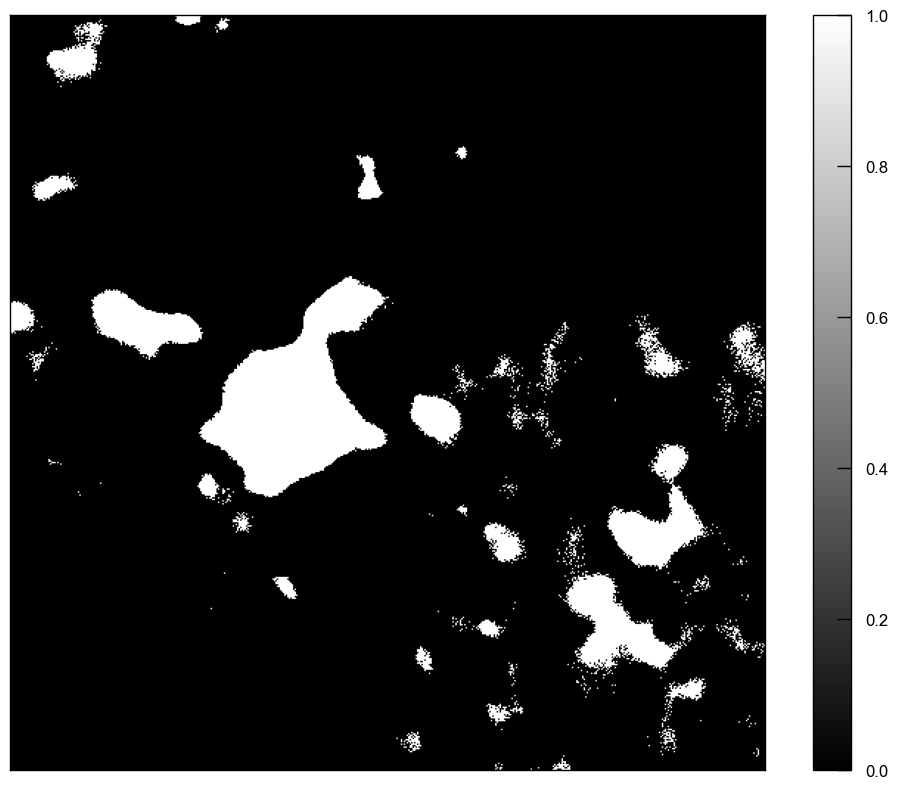

In [19]:
ax1 = plt.figure(figsize = (10,8))


plt.imshow(vacuum_mask, cmap = 'gray')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'vacuum_mask2.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
data1.data[vacuum_mask] = 0

# EDS Spectra quantification

In [20]:
sum_spectrum = data1.sum()

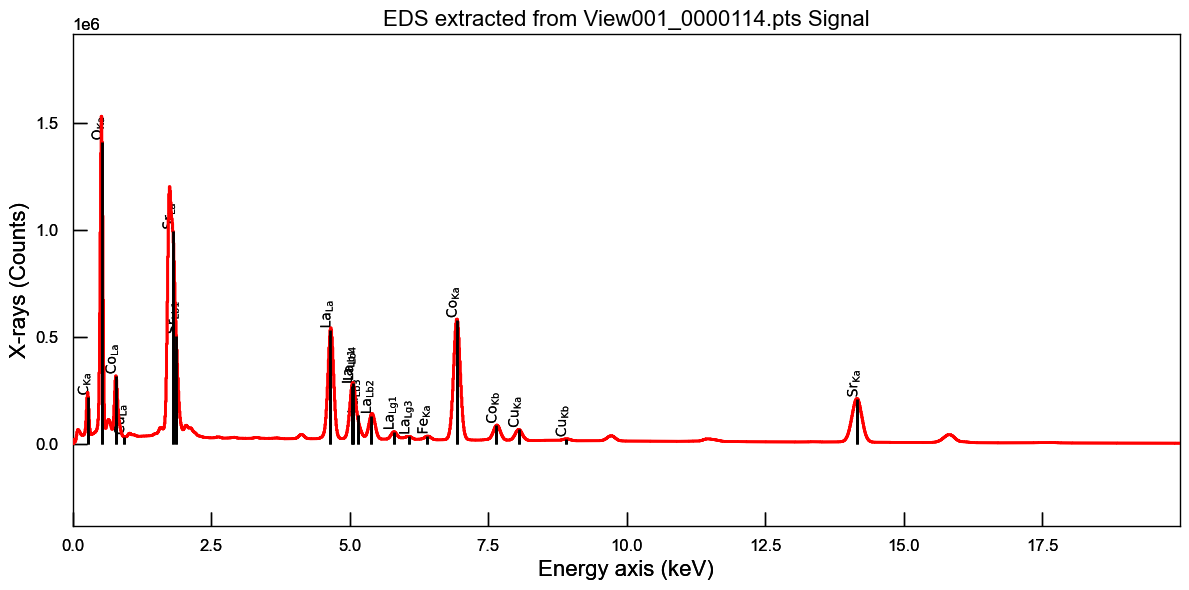

In [21]:
sum_spectrum.plot(True)

In [22]:
sum_spectrum.set_signal_type('EDS_TEM')

In [23]:
m = sum_spectrum.create_model()

In [24]:
m.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |  background_order_6 |  background_order_6 |          Polynomial
   1 |                C_Ka |                C_Ka |            Gaussian
   2 |               Co_Ka |               Co_Ka |            Gaussian
   3 |               Co_Kb |               Co_Kb |            Gaussian
   4 |               Co_La |               Co_La |            Gaussian
   5 |               Co_Ln |               Co_Ln |            Gaussian
   6 |               Co_Ll |               Co_Ll |            Gaussian
   7 |              Co_Lb3 |              Co_Lb3 |            Gaussian
   8 |               Cu_Ka |               Cu_Ka |            Gaussian
   9 |               Cu_Kb |               Cu_Kb |            Gaussian
  10 |               Cu_La |               Cu_La |            Gaussian
  11 |              Cu_Lb1 |              Cu_Lb1 |            Gaussian
  12 |

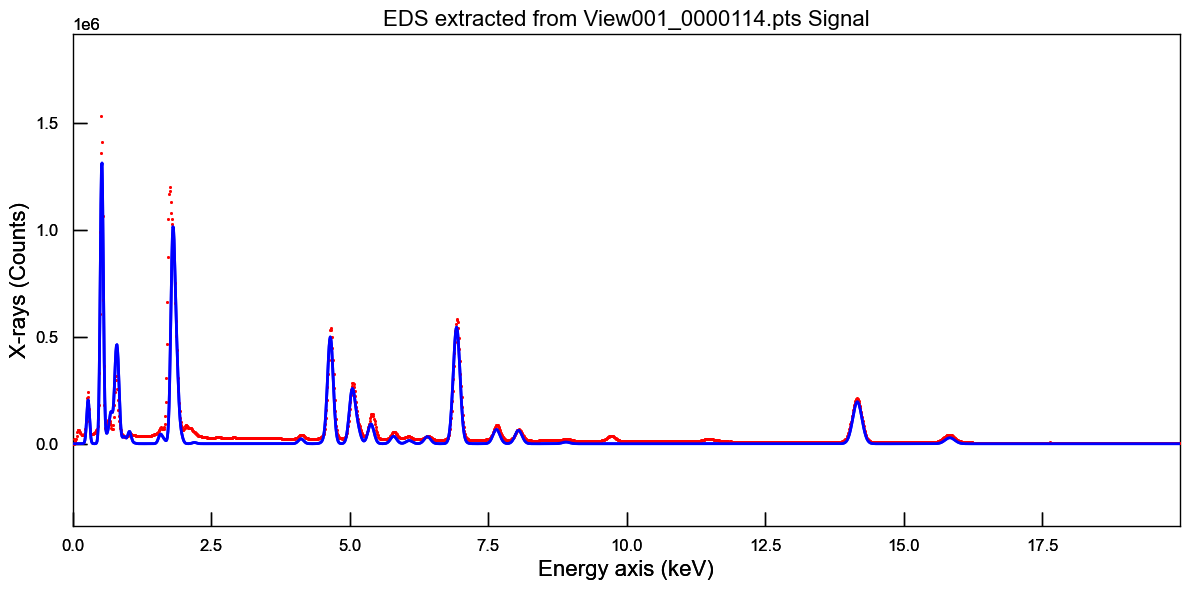

In [25]:
m.plot()

In [26]:
m.calibrate_energy_axis()


KeyboardInterrupt



In [ ]:
m.calibrate_xray_lines(calibrate = 'energy')

In [ ]:
m.calibrate_xray_lines(calibrate = 'sub_weight')

In [ ]:
m.calibrate_xray_lines(calibrate = 'width')

In [ ]:
m.fix_xray_lines_energy()

In [ ]:
m.fix_sub_xray_lines_weight()

In [27]:
m.fit()

 message: Both actual and predicted relative reductions in the sum of squares
            are at most 0.000000
 success: True
  status: 1
     fun: [ 5.637e+04  5.652e+04 ... -6.038e+03 -6.145e+03]
       x: [ 5.686e+06  1.528e+06 ...  1.049e+07  5.371e-02]
   covar: [[ 2.441e+04  1.119e+04 ... -1.639e+02 -5.115e-07]
           [ 1.119e+04  6.211e+03 ... -9.542e+01 -3.014e-07]
           ...
           [-1.639e+02 -9.542e+01 ...  1.694e+01  5.530e-08]
           [-5.115e-07 -3.014e-07 ...  5.530e-08  8.456e-16]]
    nfev: 233

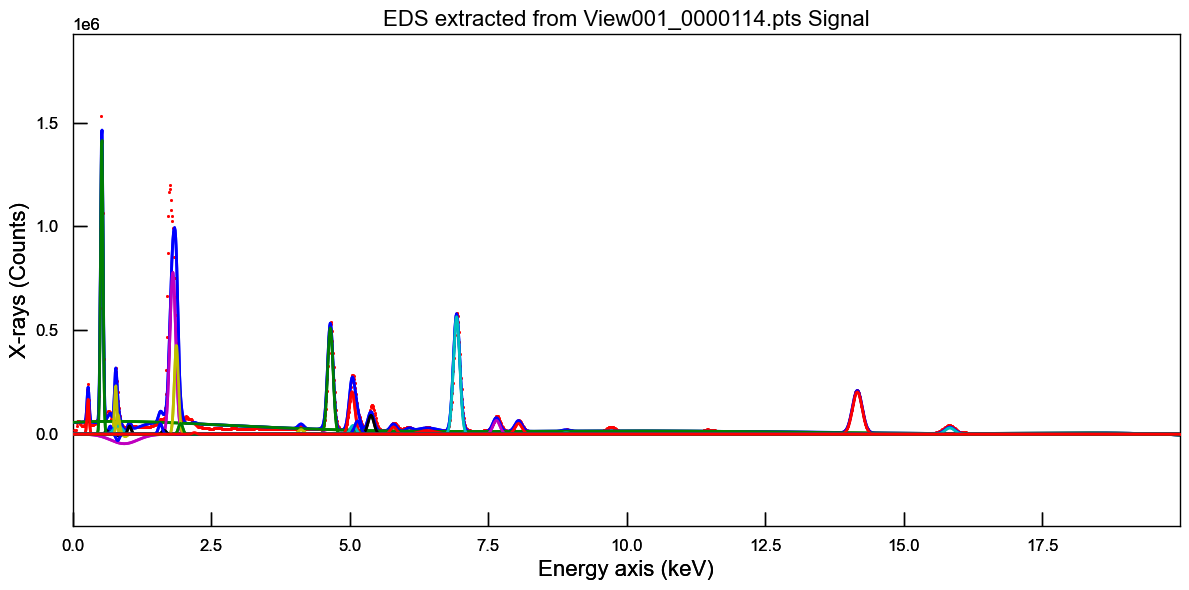

In [28]:
m.plot(plot_components = True)

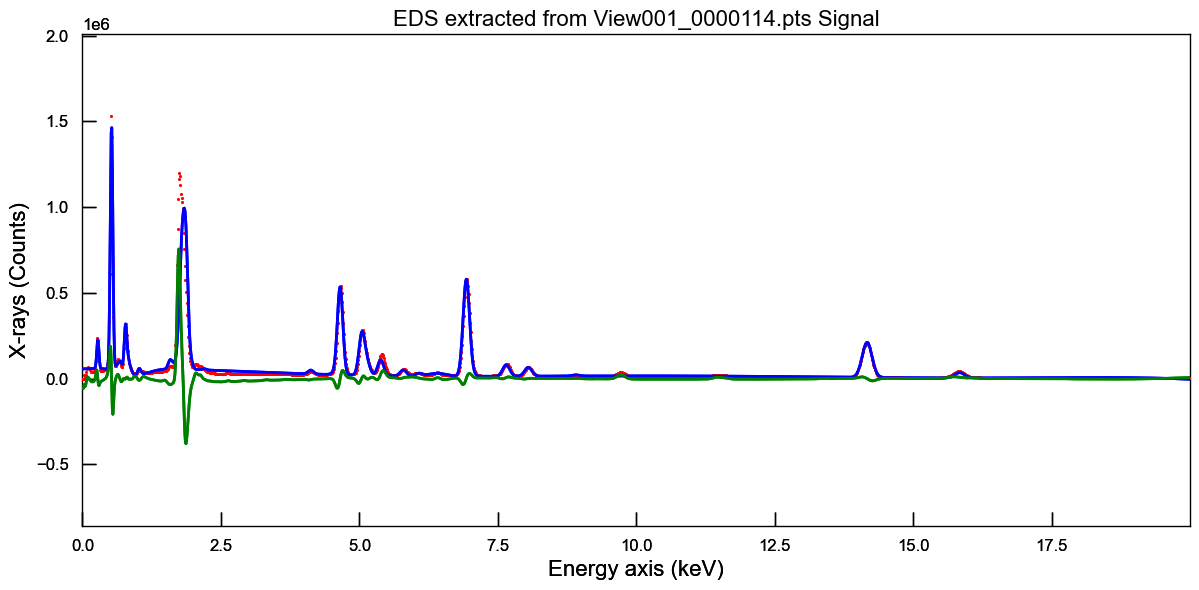

In [29]:
m.plot(plot_residual = True)

In [30]:
lines_intensities = m.get_lines_intensity(xray_lines= ['Co_Ka','La_La','Sr_Ka'])

In [31]:
kfactors = [1.747 ,4.192,5.246]# Co - 1.747 (calc) # 2.114 user #La-La 4.192 #Sr-La 3.869 Ka- 5.246

In [32]:
quant = sum_spectrum.quantification(lines_intensities, 'CL', factors=kfactors, composition_units ='atomic',plot_result =False, take_off_angle= 21.5, max_iterations = 400)

  0%|          | 0/7 [00:00<?, ?it/s]

In [33]:
print ('Co (at.%):', quant[0].data)
print ('La (at.%):', quant[1].data)
print ('Sr (at.%):', quant[2].data)

Co (at.%): [34.60937767]
La (at.%): [27.16275837]
Sr (at.%): [38.22786396]


# EDS map quantification

# Load data as Lazy signal

In [34]:
# 1. get a lazy view
s_cpu = data1.as_lazy()

# 2. pull the whole signal into RAM (in-place)
s_cpu.compute()  

  0%|          | 0/1 [00:00<?, ?it/s]

# Create model for all spectral data points

In [35]:
m_full = s_cpu.create_model(auto_add_lines= True, auto_background= True)

In [36]:
m_full.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |  background_order_6 |  background_order_6 |          Polynomial
   1 |                C_Ka |                C_Ka |            Gaussian
   2 |               Co_Ka |               Co_Ka |            Gaussian
   3 |               Co_Kb |               Co_Kb |            Gaussian
   4 |               Co_La |               Co_La |            Gaussian
   5 |               Co_Ln |               Co_Ln |            Gaussian
   6 |               Co_Ll |               Co_Ll |            Gaussian
   7 |              Co_Lb3 |              Co_Lb3 |            Gaussian
   8 |               Cu_Ka |               Cu_Ka |            Gaussian
   9 |               Cu_Kb |               Cu_Kb |            Gaussian
  10 |               Cu_La |               Cu_La |            Gaussian
  11 |              Cu_Lb1 |              Cu_Lb1 |            Gaussian
  12 |

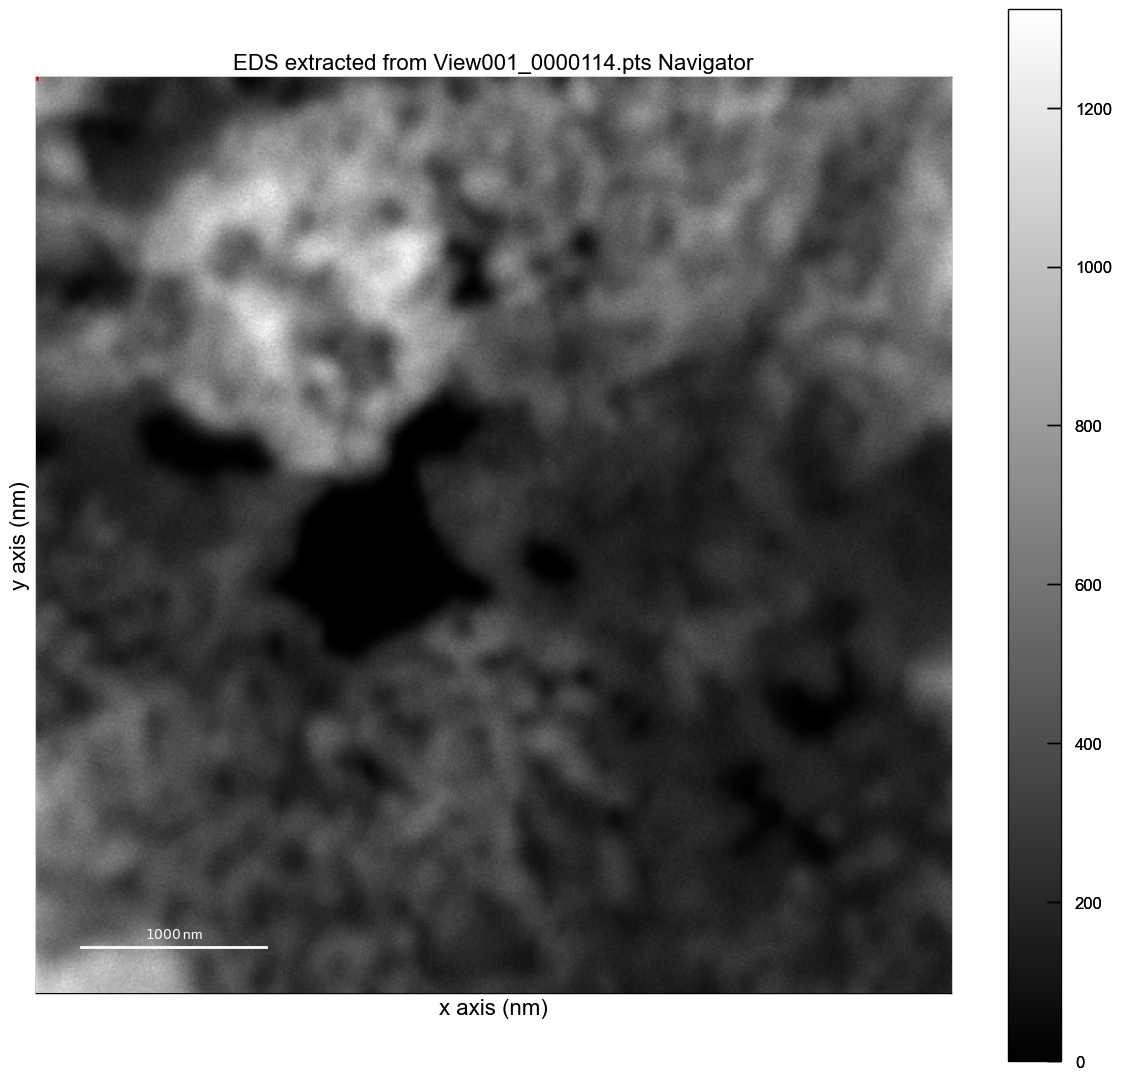

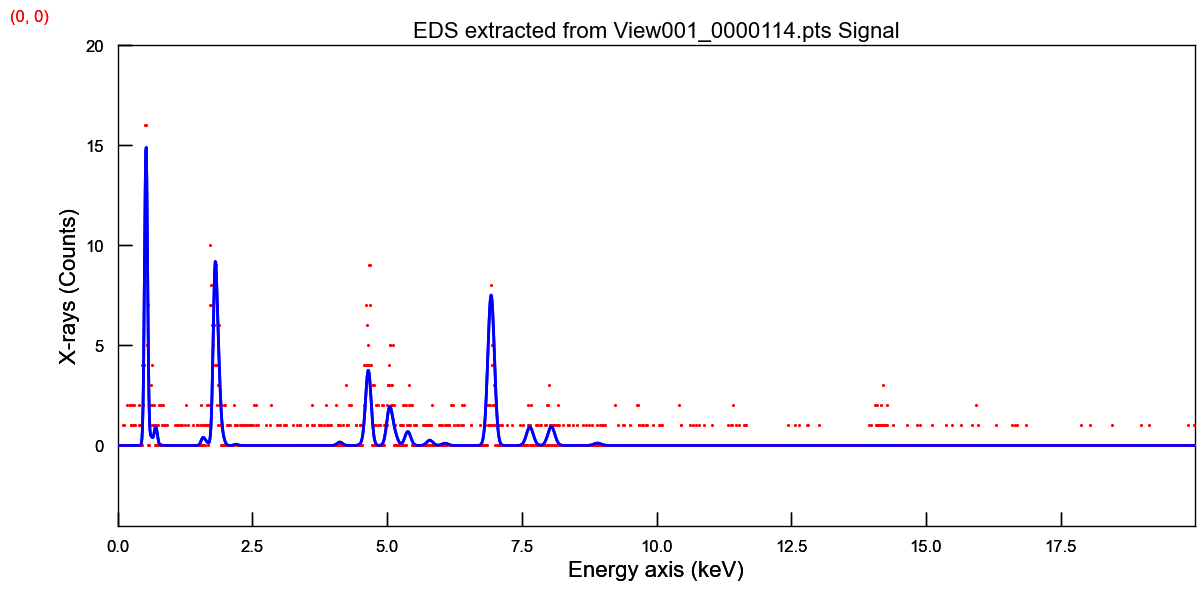

In [37]:
m_full.plot(plot_components=False)

# Fit model

In [38]:
m_full.multifit(optimizer="lstsq", loss_function = 'ls',mask = vacuum_mask)   
# CPU solve (~1 min on 8 cores)##mask values are true and will be skipped

In [39]:
intensities = m_full.get_lines_intensity(xray_lines= ['Co_Ka','La_La','Sr_Ka'])

In [40]:
intensities [0].data[intensities [0].data<0] = 0
intensities [1].data[intensities [1].data<0] = 0
intensities [2].data[intensities [2].data<0] = 0

In [41]:
#fitting residue

In [42]:
m_full.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |  background_order_6 |  background_order_6 |          Polynomial
   1 |                C_Ka |                C_Ka |            Gaussian
   2 |               Co_Ka |               Co_Ka |            Gaussian
   3 |               Co_Kb |               Co_Kb |            Gaussian
   4 |               Co_La |               Co_La |            Gaussian
   5 |               Co_Ln |               Co_Ln |            Gaussian
   6 |               Co_Ll |               Co_Ll |            Gaussian
   7 |              Co_Lb3 |              Co_Lb3 |            Gaussian
   8 |               Cu_Ka |               Cu_Ka |            Gaussian
   9 |               Cu_Kb |               Cu_Kb |            Gaussian
  10 |               Cu_La |               Cu_La |            Gaussian
  11 |              Cu_Lb1 |              Cu_Lb1 |            Gaussian
  12 |

In [ ]:
#model_data = m_full.as_signal(component_list= [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19])####no plotting window must be open 
model_data = m_full.as_signal(component_list= [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
                                              ,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
                                              ,37,38,39,40,41,42,43])
model_data.axes_manager = data1.axes_manager

In [ ]:
##quick way to estimate global or average fitting
plt.figure()

plt.plot(data1.axes_manager[-1].axis,model_data.sum(),label = "Model, sum of all pixel")
plt.plot(data1.axes_manager[-1].axis,data1.sum(),label = "Data, sum of all pixels")
plt.plot(data1.axes_manager[-1].axis,data1.sum()-model_data.sum(),label = "Residue")

plt.legend()



In [ ]:
plt.savefig(r'Sum-spectrum_fit2.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
plt.savefig(r'Sum-spectrum_fit2.svg', dpi=600, format='svg', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
residue = (data1 - model_data).data
rel_err = np.sqrt(np.sum(residue**2, axis =2)/(np.sum(data1.data**2,axis =2)))

rel_err[np.isnan(rel_err)] =0
rel_err[np.isinf(rel_err)] =0

In [ ]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(rel_err, cmap = 'turbo', interpolation = 'none')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
plt.figure ()
x = rel_err.ravel()
y = total_counts.ravel()

plt.scatter(x, y, s=1, alpha = 0.5,)
plt.ylim(-1, total_counts.max()+100)
plt.xlim(rel_err.min()-0.05, rel_err.max()+0.05)
plt.xlabel("Total residue")
plt.ylabel("Total counts per pixel")
plt.show()


In [ ]:
plt.savefig(r'L2_total_counts.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
plt.savefig(r'L2_total_counts.svg', dpi=600, format='svg', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
La_raw = data1.isig[4.4:4.85]
La_model  = model_data.isig[4.4:4.85]

Co_raw = data1.isig[6.65:7.27]
Co_model = model_data.isig[6.65:7.27]

Sr_raw = data1.isig[13.9: 14.4]
Sr_model = model_data.isig[13.9: 14.4]
#Sr_model = model_data.isig[1.67: 2.0]

In [ ]:
La_residue = (La_raw - La_model).data
La_rel_err = np.sqrt(np.sum(La_residue**2, axis =2)/(np.sum(La_raw.data**2,axis =2)))
La_rel_err[np.isnan(La_rel_err)] =0
La_rel_err[np.isinf(La_rel_err)] =0

In [ ]:
Co_residue = (Co_raw - Co_model).data
Co_rel_err = np.sqrt(np.sum(Co_residue**2, axis =2)/(np.sum(Co_raw.data**2,axis =2)))
Co_rel_err[np.isnan(Co_rel_err)] =0
Co_rel_err[np.isinf(Co_rel_err)] =0

In [ ]:
Sr_residue = (Sr_raw - Sr_model).data
Sr_rel_err = np.sqrt(np.sum(Sr_residue**2, axis =2)/(np.sum(Sr_raw.data**2,axis =2)))
Sr_rel_err[np.isnan(Sr_rel_err)] =0
Sr_rel_err[np.isinf(Sr_rel_err)] =0

In [ ]:
max_value  = max(La_rel_err.max(), Sr_rel_err.max(), Co_rel_err.max())

In [ ]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(La_rel_err, cmap = 'turbo', vmax = max_value)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('La_L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'La_L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(Co_rel_err, cmap = 'turbo', vmax = max_value, interpolation = 'none')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('Co_L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'Co_L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(Sr_rel_err, cmap = 'turbo', vmax = max_value, interpolation = 'none')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('Sr_L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'Sr_L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [44]:
kfactors = [1.747 ,4.192,5.246]# Co - 1.747 (calc) # 2.114 user #La-La 4.192 #Sr-La 3.869 Ka- 5.246

In [45]:
quant = data1.quantification(intensities, 'CL', factors=kfactors, composition_units ='atomic', navigation_mask = vacuum_mask,plot_result =False, take_off_angle= 21.5, max_iterations = 400)

C:\Users\nagaa\HyperSpy-bundle\Lib\site-packages\exspy\_misc\eds\utils.py:523: RuntimeWarning: divide by zero encountered in scalar divide
  (intensities[ref_index] * absorption_correction[ref_index])


  0%|          | 0/7 [00:00<?, ?it/s]

C:\Users\nagaa\HyperSpy-bundle\Lib\site-packages\exspy\_misc\material.py:67: RuntimeWarning: invalid value encountered in divide
  atomic_percent[i] /= sum_weight


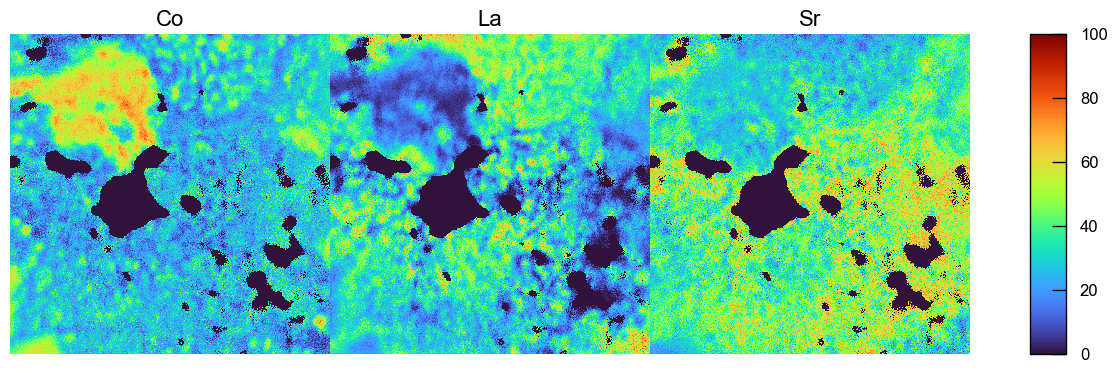

In [46]:
map_plot = hs.plot.plot_images(quant,
        tight_layout=False,cmap= 'turbo', axes_decor='off', vmin = 0, vmax =100,
        colorbar='single', label = ['Co','La','Sr'], scalebar = None, interpolation = 'none',
                               scalebar_color='white', padding={'top':0.9, 'bottom':0.10, 'left':0.05,
                                         'right':0.85, 'wspace':0.0, 'hspace':0.05})

In [ ]:

plt.savefig(r'Quant_map_Sr.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:

plt.savefig(r'Quant_map_La.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:

plt.savefig(r'Quant_map_Co.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [47]:
quant

[<BaseSignal, title: atomic percent of Co, dimensions: (512, 512|)>,
 <BaseSignal, title: atomic percent of La, dimensions: (512, 512|)>,
 <BaseSignal, title: atomic percent of Sr, dimensions: (512, 512|)>]

# Composition distribution

In [48]:
Co_map = quant[0].data
La_map = quant[1].data
Sr_map = quant[2].data

In [49]:
La_map[np.isnan(La_map)] = 0
Co_map[np.isnan(Co_map)] = 0
Sr_map[np.isnan(Sr_map)] = 0

C:\Users\nagaa\HyperSpy-bundle\Lib\site-packages\mpltern\ternary\transforms.py:290: RuntimeWarning: invalid value encountered in divide
  return (values / np.sum(values, axis=1)[:, None]) @ self.corners


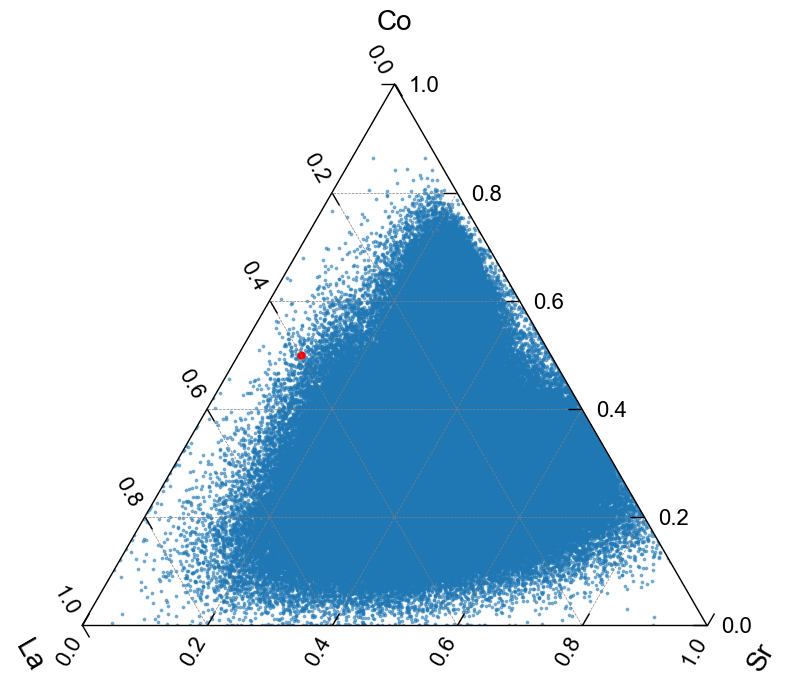

In [50]:
#Ternary plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpltern

# --- Flatten raw maps into 1D arrays ---
sr_vals = Sr_map.flatten()
la_vals = La_map.flatten()
co_vals = Co_map.flatten()

# --- Compute total composition per pixel ---
total = sr_vals + la_vals + co_vals

# --- Filtering conditions ---
valid_pixels = (total == 100)

# --- Apply mask to get valid data points ---
sr_valid = sr_vals
la_valid = la_vals
co_valid = co_vals



# --- Plot using mpltern ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='ternary')

# Scatter plot with Sr color mapping (absolute raw Sr values)
sc = ax.scatter(co_valid, la_valid, sr_valid,
                 s=3, alpha=0.5)#c=sr_valid, cmap='turbo',
target = ax.scatter(50, 40, 10, c = 'red', s = 25, alpha = 1.0)

# Axis labels (keeping the same convention as Plotly a=Co, b=La, c=Sr)
ax.set_rlabel("Sr", fontsize = 20)
ax.set_llabel("La", fontsize = 20)
ax.set_tlabel("Co", fontsize = 20)

# Grid lines and ticks styling
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()

plt.show()


In [ ]:
plt.savefig(r'ternary.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

Mean_Sr: 40.43, Std: 12.69, Skewness: 0.22
Mean_La: 29.39, Std: 13.79, Skewness: 0.24
Mean_Co: 30.26, Std: 13.45, Skewness: 0.94


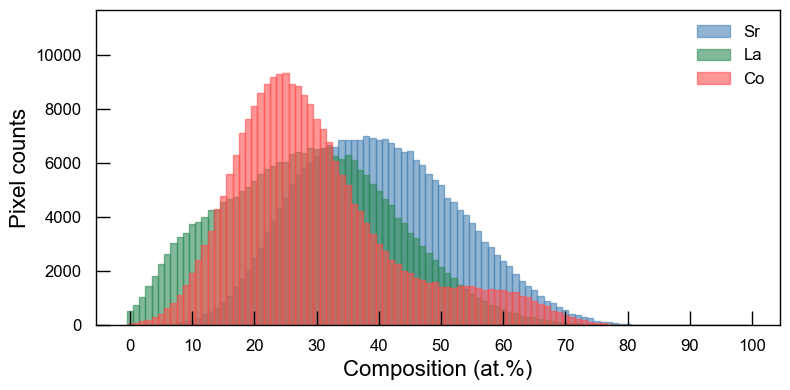

In [51]:
from scipy.stats import norm, skew
# Example data: 1024x1024 array with values between 0 and 100
array_Sr = Sr_map
array_La = La_map
array_Co = Co_map

non_zero_values_Sr = array_Sr[array_Sr > 0]
non_zero_values_La = array_La[array_La > 0]
non_zero_values_Co = array_Co[array_Co > 0]

# Compute histogram
counts_Sr, bin_edges_Sr = np.histogram(non_zero_values_Sr, bins=100, range=(0, 100),)
counts_La, bin_edges_La = np.histogram(non_zero_values_La, bins=100, range=(0, 100),)
counts_Co, bin_edges_Co = np.histogram(non_zero_values_Co, bins=100, range=(0, 100),)

# Compute statistical parameters
mean_Sr = np.mean(non_zero_values_Sr)
std_Sr = np.std(non_zero_values_Sr)
skewness_Sr = skew(non_zero_values_Sr)

mean_La = np.mean(non_zero_values_La)
std_La = np.std(non_zero_values_La)
skewness_La = skew(non_zero_values_La)

mean_Co = np.mean(non_zero_values_Co)
std_Co = np.std(non_zero_values_Co)
skewness_Co = skew(non_zero_values_Co)

print(f"Mean_Sr: {mean_Sr:.2f}, Std: {std_Sr:.2f}, Skewness: {skewness_Sr:.2f}")
print(f"Mean_La: {mean_La:.2f}, Std: {std_La:.2f}, Skewness: {skewness_La:.2f}")
print(f"Mean_Co: {mean_Co:.2f}, Std: {std_Co:.2f}, Skewness: {skewness_Co:.2f}")

# Plot histogram and Gaussian curve
plt.figure(figsize=(8, 4))
plt.bar(bin_edges_Sr[:-1], counts_Sr, width=bin_edges_Sr[1] - bin_edges_Sr[0],
        color='steelblue', edgecolor='steelblue', alpha=0.6, label='Sr')

plt.bar(bin_edges_La[:-1], counts_La, width=bin_edges_La[1] - bin_edges_La[0],
        color ='seagreen' ,edgecolor='seagreen', alpha=0.6, label='La')

plt.bar(bin_edges_Co[:-1], counts_Co, width=bin_edges_Co[1] - bin_edges_Co[0],
        color='#ff5050', edgecolor='#ff5050', alpha=0.6, label='Co')

plt.xlabel("Composition (at.%)")
plt.ylabel("Pixel counts")
plt.legend(frameon = False)
plt.xticks([0,10,20,30,40,50,60,70,80,90,100])
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'Quant_map_histogram.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

# Cluster map


Cluster Summary (Ordered by Sr):
   Cluster  Fraction    Mean_Co    Mean_La    Mean_Sr  New_Cluster
0        2  0.084026   0.000000   0.000000   0.000000            0
1        0  0.125980  56.293220  13.880085  29.826695            1
2        4  0.244659  33.797599  32.486030  33.716371            2
3        1  0.238575  19.020066  46.069938  34.909996            3
4        3  0.306759  25.465147  20.128061  54.406792            4


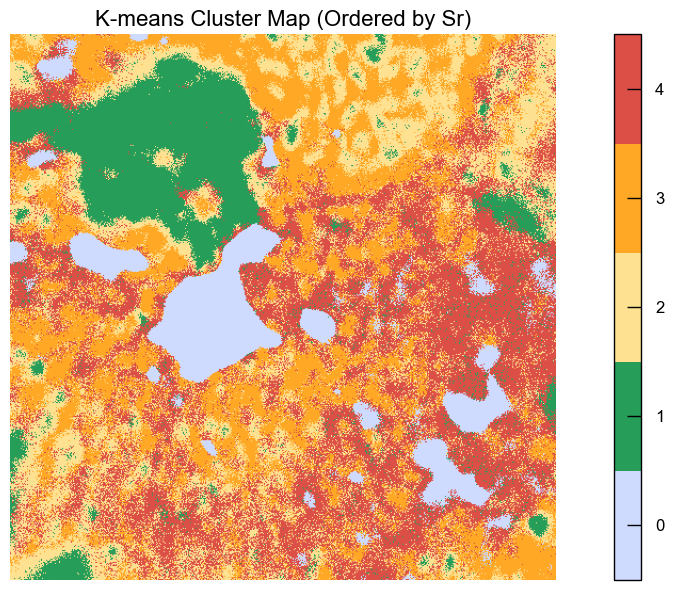

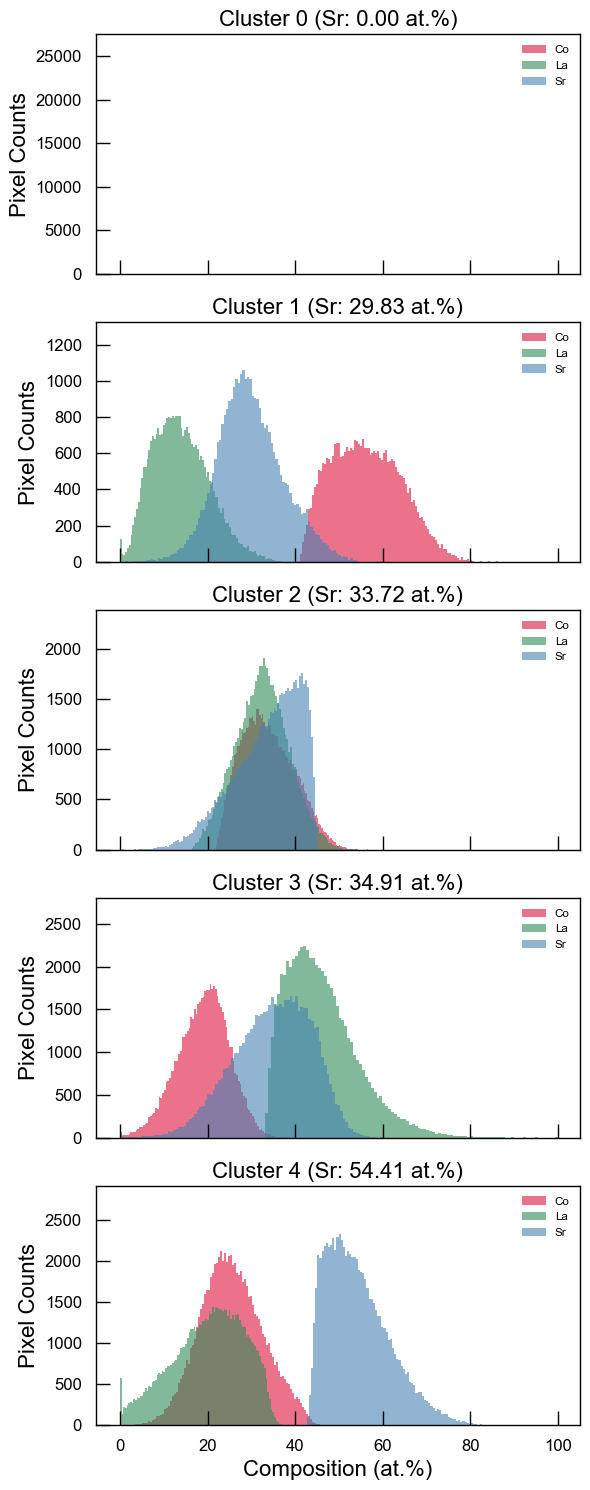

In [52]:
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ----------------------------
# Rebin function
def rebin(arr, new_shape):
    """Rebin 2D array to smaller shape by averaging."""
    shape = (new_shape[0], arr.shape[0] // new_shape[0],
             new_shape[1], arr.shape[1] // new_shape[1])
    return arr.reshape(shape).mean(-1).mean(1)

# ----------------------------
# Rebin element maps
target_shape = (512, 512)
co_map = rebin(Co_map, target_shape)
la_map = rebin(La_map, target_shape)
sr_map = rebin(Sr_map, target_shape)

# ----------------------------
# Prepare data for clustering
X = np.stack([co_map.ravel(), la_map.ravel(), sr_map.ravel()], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# Run KMeans clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)
labels_image = labels.reshape(target_shape)

# ----------------------------
# Compute cluster statistics
cluster_stats = []
for i in range(n_clusters):
    mask = labels == i
    cluster_stats.append({
        'Cluster': i,
        'Fraction': np.sum(mask) / len(labels),
        'Mean_Co': co_map.ravel()[mask].mean(),
        'Mean_La': la_map.ravel()[mask].mean(),
        'Mean_Sr': sr_map.ravel()[mask].mean()
    })

df_clusters = pd.DataFrame(cluster_stats)

# ----------------------------
# Reorder clusters based on ascending Sr
sorted_clusters = df_clusters.sort_values('Mean_Sr')['Cluster'].tolist()
cluster_remap = {old: new for new, old in enumerate(sorted_clusters)}

# Apply relabeling
labels_remapped = np.vectorize(cluster_remap.get)(labels)
labels_image_remapped = labels_remapped.reshape(target_shape)

# Remap and sort stats for reporting and histogram plotting
df_clusters['New_Cluster'] = df_clusters['Cluster'].map(cluster_remap)
df_clusters = df_clusters.sort_values('New_Cluster').reset_index(drop=True)

print("\nCluster Summary (Ordered by Sr):")
print(df_clusters)

# ----------------------------
# Plot cluster map
cluster_colors = ['#ccd9ff',  # blue
                  '#1a9850',  # green
                  '#fee08b',  # yellow-orange
                  '#ffa31a',  # yellow                
                  '#db453d',  # red
                 '#7e00dd',
                 '#D327F5',
                 '#8FFACB',
                 '#275BF5',
                 '#F5CF27',]  
custom_cmap = ListedColormap(cluster_colors[:n_clusters])

plt.figure()
plt.imshow(labels_image_remapped, cmap=custom_cmap, alpha=0.95)
plt.title('K-means Cluster Map (Ordered by Sr)')
plt.axis('off')

# Colorbar
cbar = plt.colorbar(ticks=np.arange(n_clusters))
cbar.ax.set_yticklabels([f'Cluster {i}' for i in range(n_clusters)])
plt.clim(-0.5, n_clusters - 0.5)
plt.tight_layout()
plt.show()

# ----------------------------
# Histograms by reordered clusters
bins = 100
fig, axes = plt.subplots(n_clusters, 1,
                         figsize=(6, 3 * n_clusters),
                         sharex=True)

for i, ax in enumerate(axes):
    mask = labels_remapped == i  # <== use remapped labels here
    ax.hist(co_map.ravel()[mask], bins=bins, density=False,
            alpha=0.6, label='Co', color='crimson')
    ax.hist(la_map.ravel()[mask], bins=bins, density=False,
            alpha=0.6, label='La', color='seagreen')
    ax.hist(sr_map.ravel()[mask], bins=bins, density=False,
            alpha=0.6, label='Sr', color='steelblue')
    
    ax.set_title(f'Cluster {i} (Sr: {df_clusters.loc[i, "Mean_Sr"]:.2f} at.%)')
    ax.set_ylabel('Pixel Counts')
    ax.legend(frameon=False, fontsize='small')

axes[-1].set_xlabel('Composition (at.%)')
fig.tight_layout()
plt.show()


In [ ]:
df_clusters.to_excel("df_clusters_512x512.xlsx")

In [ ]:
plt.savefig(r'Cluster_map_histogram.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
plt.savefig(r'Cluster_map.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

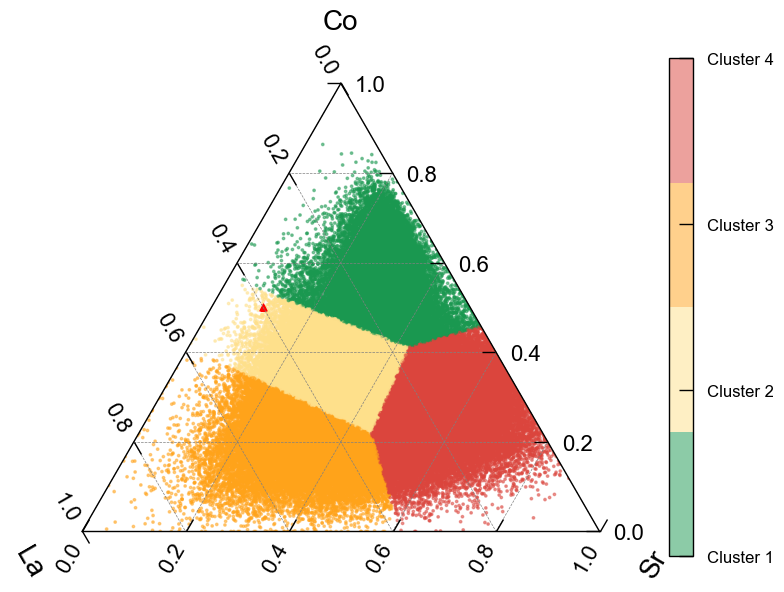

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpltern
from matplotlib.colors import ListedColormap

# Assume cluster 0 (vacuum) has already been removed from labels_image_remapped
# and that you have exactly 4 remaining clusters: 0, 1, 2, 3 (Sr-sorted)

n_clusters = 4
cluster_colors = [
    '#1a9850',  # Cluster 0 (green)
    '#fee08b',  # Cluster 1 (yellow-orange)
    '#ffa31a',  # Cluster 2 (yellow)
    '#db453d'   # Cluster 3 (red)
]
custom_cmap = ListedColormap(cluster_colors)

# --- Flatten rebinned maps and labels ---
sr_vals = Sr_map.flatten()
la_vals = La_map.flatten()
co_vals = Co_map.flatten()
label_vals = labels_image_remapped.flatten()  # ✅ Use remapped labels!

# --- Total composition per pixel ---
total = sr_vals + la_vals + co_vals
valid_mask = (total == 100) & (label_vals >= 0)  # ✅ Mask out vacuum (-1)

# --- Apply mask ---
sr_valid = sr_vals[valid_mask]
la_valid = la_vals[valid_mask]
co_valid = co_vals[valid_mask]
cluster_valid = label_vals[valid_mask]

# --- Ternary plot ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='ternary')

sc = ax.scatter(co_valid, la_valid, sr_valid,
                c=cluster_valid, cmap=custom_cmap,
                s=3, alpha=0.5)

# Optional target
ax.scatter(50, 40, 10, c='red', s=25, alpha=1.0, marker='^')

# Labels
ax.set_rlabel("Sr", fontsize=20)
ax.set_llabel("La", fontsize=20)
ax.set_tlabel("Co", fontsize=20)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.tick_params(axis='both', labelsize=16)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, ticks=np.arange(n_clusters+1), shrink=0.75, pad=0.1)
cbar.ax.set_yticklabels([f'Cluster {i}' for i in range(0,5,1)])

plt.tight_layout()
plt.show()


In [ ]:
plt.savefig(r'Cluster_map_ternary.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

# Extract line profile

In [54]:
#python arrranges the base signal in alphabetical order of the elements
Sr_profile = quant[2].as_signal1D(0)
La_profile = quant[1].as_signal1D(0)
Co_profile = quant[0].as_signal1D(0)

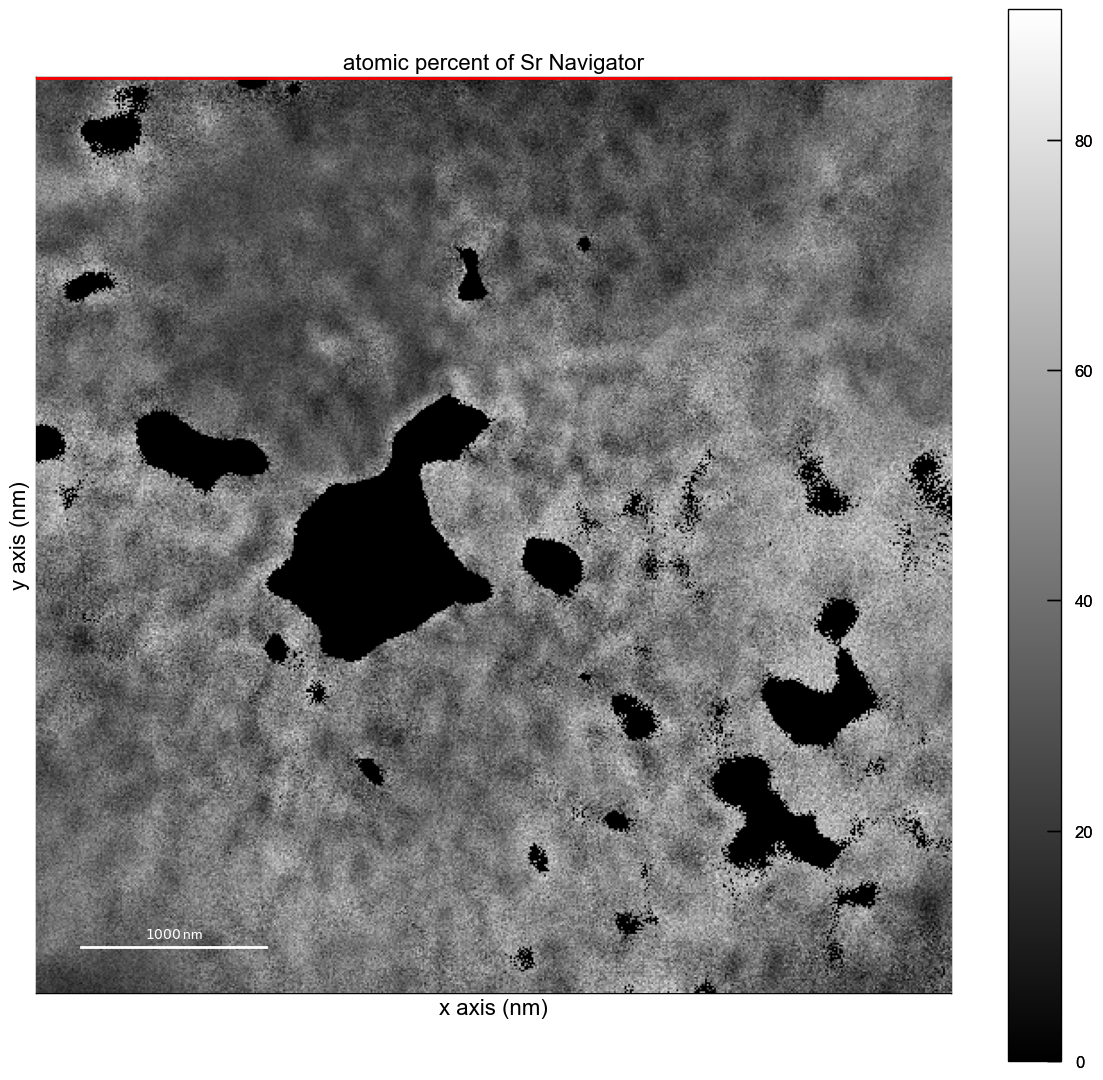

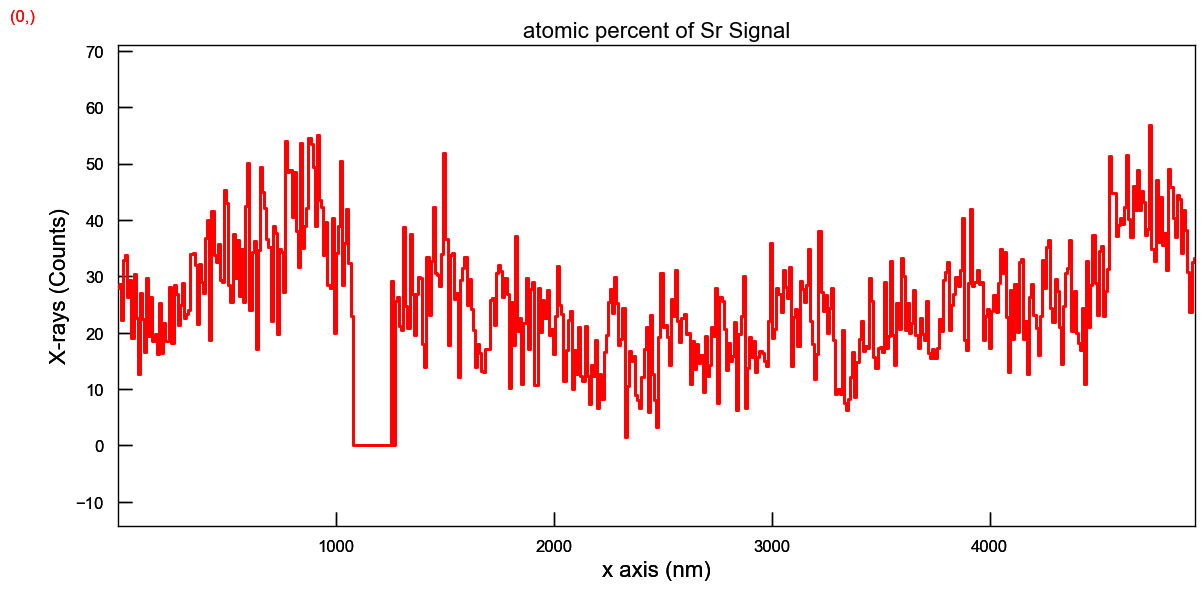

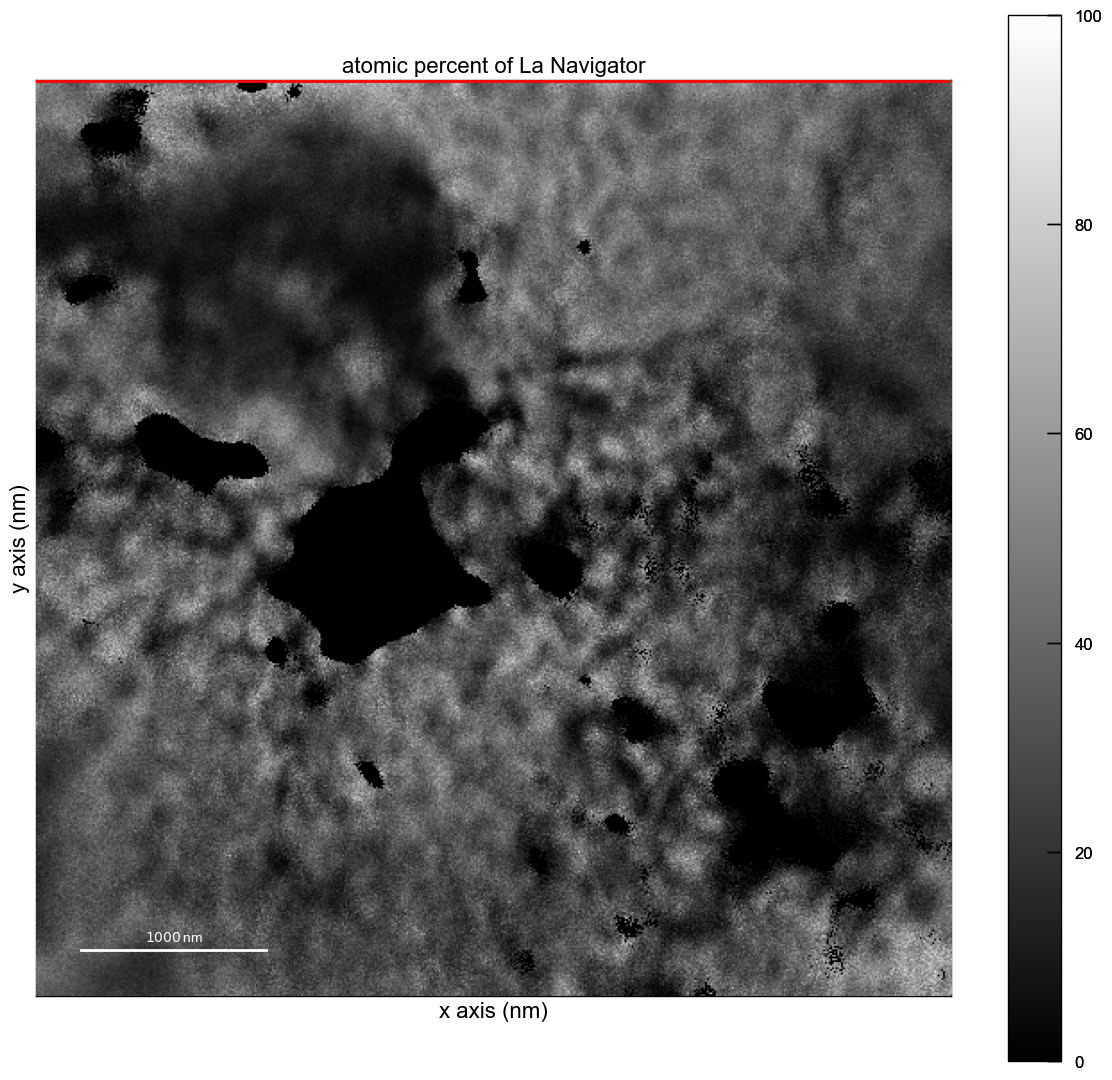

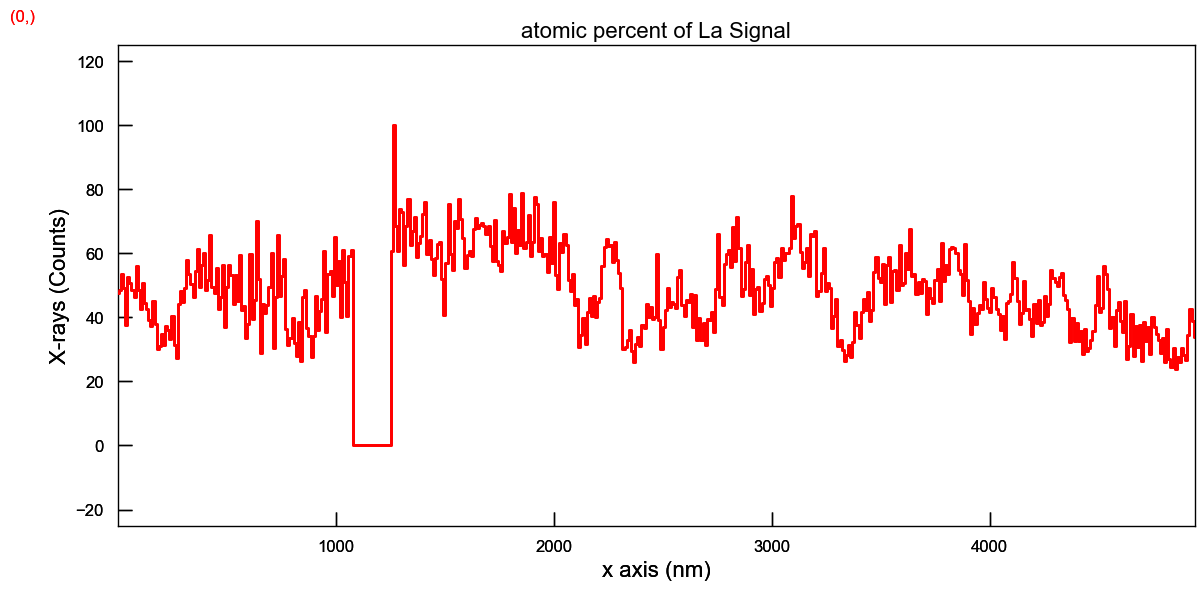

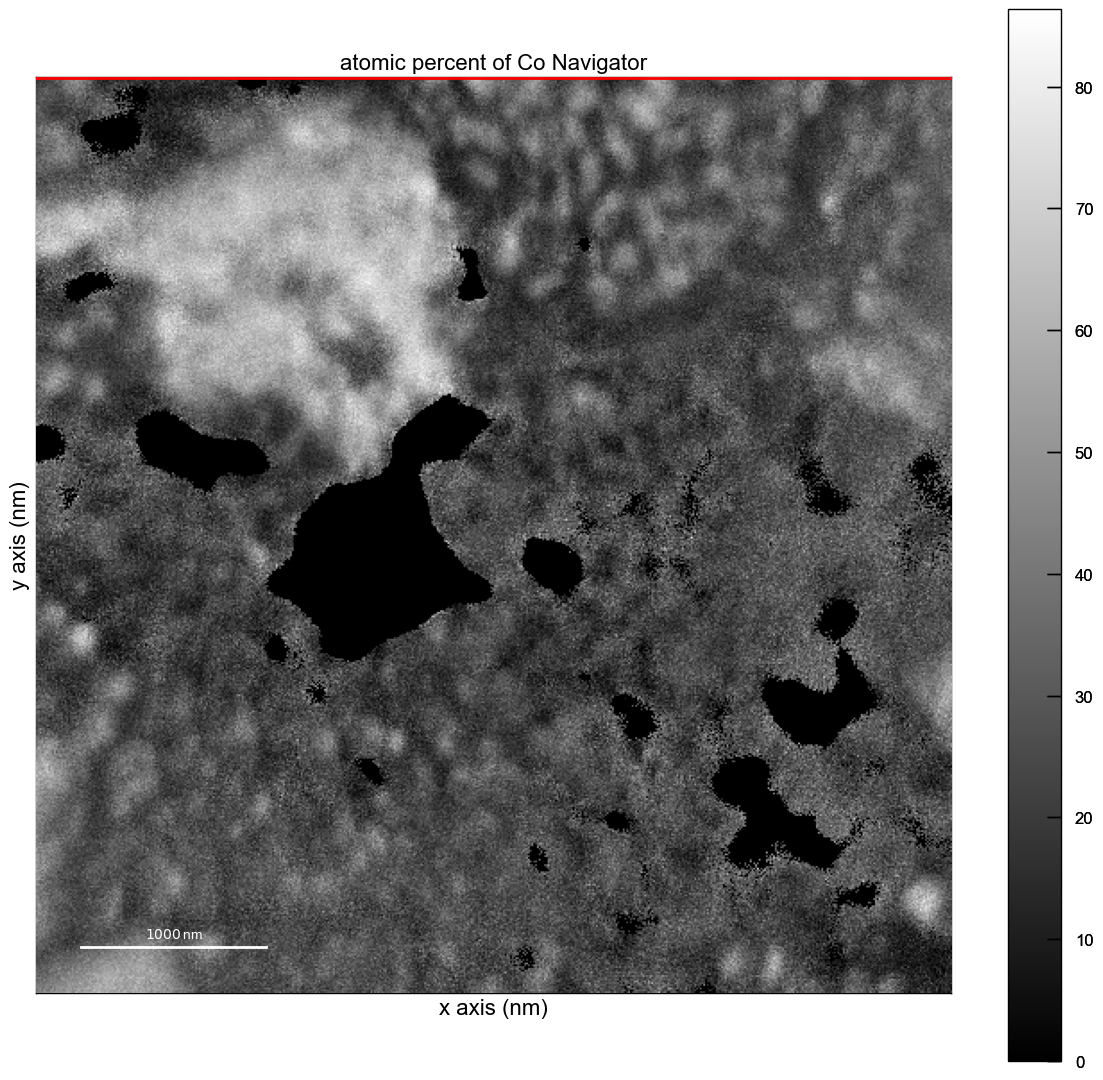

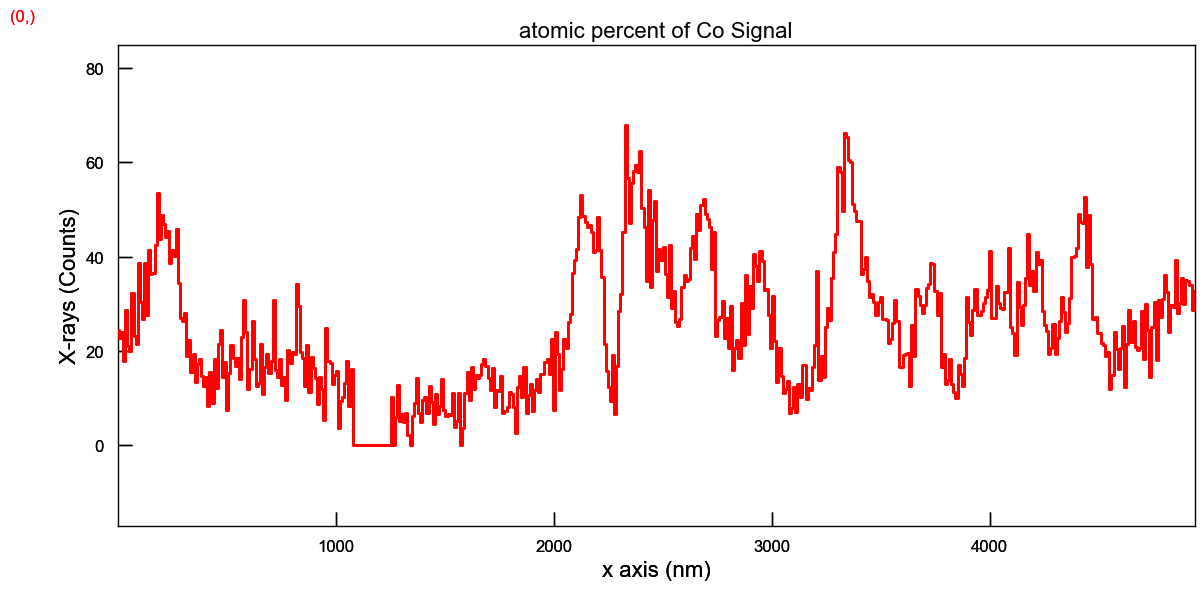

In [55]:
Sr_profile.plot()
La_profile.plot()
Co_profile.plot()

In [56]:
line_roi = hs.roi.Line2DROI(102, 76, 92, 143, linewidth = 5)
color = ["tab:blue", "tab:green" , "tab:red"]
roi_Sr = line_roi.interactive(Sr_profile, color= color[0])
roi_La = line_roi.interactive(La_profile, color= color[1])
roi_Co = line_roi.interactive(Co_profile, color= color[2])

([<matplotlib.axis.YTick at 0x1995373af00>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90'),
  Text(0, 100, '100')])

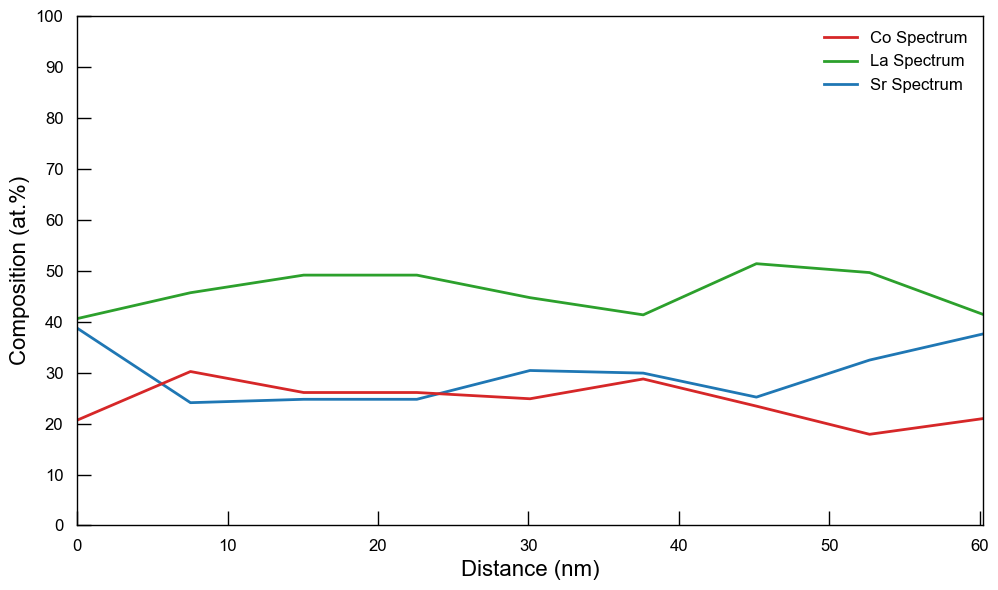

In [57]:

ax = hs.plot.plot_spectra([roi_Sr, roi_La, roi_Co], color = color, legend = ['Sr Spectrum', 'La Spectrum', 'Co Spectrum'], figsize=(10, 6))


plt.ylim(0, 80)
plt.xlabel('Distance (nm)') 
plt.ylabel('Composition (at.%)') 
plt.tight_layout()
#plt.legend()
ax.get_legend().set_frame_on(False)
plt.yticks([0,10,20,30,40,50,60,70,80,90,100])